# Basic utils for Investing based on Indicators

## Imports

In [113]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import random
import plotly.express as px

seed = 1

# Attribution d'une graine.
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

%reload_ext autoreload
%autoreload 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch_dtype = torch.float32

## Data reading and processing

In [114]:
pair = 'SOLUSDT'
timeframe = '5m'
type_data = 'Futures'

# Importation des données


data = pd.read_csv(f'../data/binance/{pair}_{timeframe}_{type_data}.csv', parse_dates=[0], index_col=0)
data

,Open,High,Low,Close,Volume,Qav,Trades,Taker_base_vol,Taker_quote_vol
Date,,,,,,,,,
2020-09-14 09:00:00,3.2002,4.9100,3.2002,3.3045,42698,1.426940e+05,640,15267,5.195271e+04
2020-09-14 09:05:00,3.3045,3.3974,3.2844,3.3497,51149,1.712361e+05,1152,28120,9.440854e+04
2020-09-14 09:10:00,3.3486,3.3576,3.3151,3.3393,23974,7.976511e+04,675,6843,2.276923e+04
2020-09-14 09:15:00,3.3443,3.4189,3.3353,3.3834,65640,2.223665e+05,1231,24917,8.447305e+04
2020-09-14 09:20:00,3.3855,3.4149,3.3709,3.3787,55165,1.865342e+05,825,11150,3.776340e+04
...,...,...,...,...,...,...,...,...,...
2024-09-04 19:35:00,133.0160,133.2070,132.5270,132.9030,173991,2.312146e+07,13635,64643,8.591545e+06
2024-09-04 19:40:00,132.9040,133.3170,132.7000,132.7360,72642,9.664593e+06,6799,36578,4.867733e+06
2024-09-04 19:45:00,132.7360,133.1360,132.7330,133.0310,43489,5.781083e+06,4668,24068,3.199412e+06


In [115]:
data.loc[:, '%R'] = data['Close'].pct_change()*100

# quatiles_threshold = 0.00001

# plt.figure(figsize=(20, 10))

# plt.subplot(2, 2, 1)    
# plt.hist(data['%R'] , bins=500, density=True)

# plt.subplot(2, 2, 3)
# plt.plot(data['%R'])

# # data['%R'] = data['%R'].clip(lower=data['%R'].quantile(quatiles_threshold), upper=data['%R'].quantile(1-quatiles_threshold))

# print(data['%R'].mean())

# # data['%R'] = data['%R'] - data['%R'].mean()

# plt.subplot(2, 2, 2)
# plt.hist(data['%R'], bins=500, density=True)

# plt.subplot(2, 2, 4)
# plt.plot(data['%R'])

# plt.show()

In [116]:
import ta

df = data[['%R']].copy()
df.loc[:, '%H'] = (data.loc[:, 'High'] - data.loc[:, 'Close'].shift(1)) / data.loc[:, 'Close'].shift(1) * 100
df.loc[:, '%L'] = (data.loc[:, 'Low'] - data.loc[:, 'Close'].shift(1)) / data.loc[:, 'Close'].shift(1) * 100

# df['%R2'] = df['%R']**2 # no gain

# df['RSI_14'] = ta.momentum.rsi(df['%R'], window=14) # gain
# df['RSI_7'] = ta.momentum.rsi(df['%R'], window=7) # gain
# df['RSI_112'] = ta.momentum.rsi(df['%R'], window=112) # no gain
# df['RSI_21'] = ta.momentum.rsi(df['%R'], window=21) # gain
# df['RSI_28'] = ta.momentum.rsi(df['%R'], window=28) # gain
# df['RSI_35'] = ta.momentum.rsi(df['%R'], window=35) # no gain

df['RSI_14'] = ta.momentum.rsi(data['Close'], window=14) # gain
# df['RSI_7'] = ta.momentum.rsi(data['Close'], window=7) # gain
df['RSI_112'] = ta.momentum.rsi(data['Close'], window=112) # gain


# df['MACD_12/26'] = ta.trend.macd(data['Close'], window_slow=26, window_fast=12) # gain



df.dropna(inplace=True)

In [117]:
df.describe()

,%R,%H,%L,RSI_14,RSI_112
count,417909.000000,417909.000000,417909.000000,417909.000000,417909.000000
mean,0.001821,0.261946,-0.263483,50.089395,50.059804
std,0.434316,0.377850,0.361442,11.255227,4.202666
min,-16.548129,-0.258249,-19.052498,3.540648,26.010704
25%,-0.165861,0.066600,-0.334608,42.657553,47.364922
50%,0.000000,0.162962,-0.163458,50.025851,49.913195
75%,0.166017,0.330533,-0.064712,57.470525,52.703616
max,23.072171,39.864100,0.262762,97.659776,80.322898


In [118]:
columns_data = ['%R', 
                # '%H', 
                # '%L', 
                'RSI_14', 
                'RSI_112']
columns_target = ['%R', '%H', '%L']


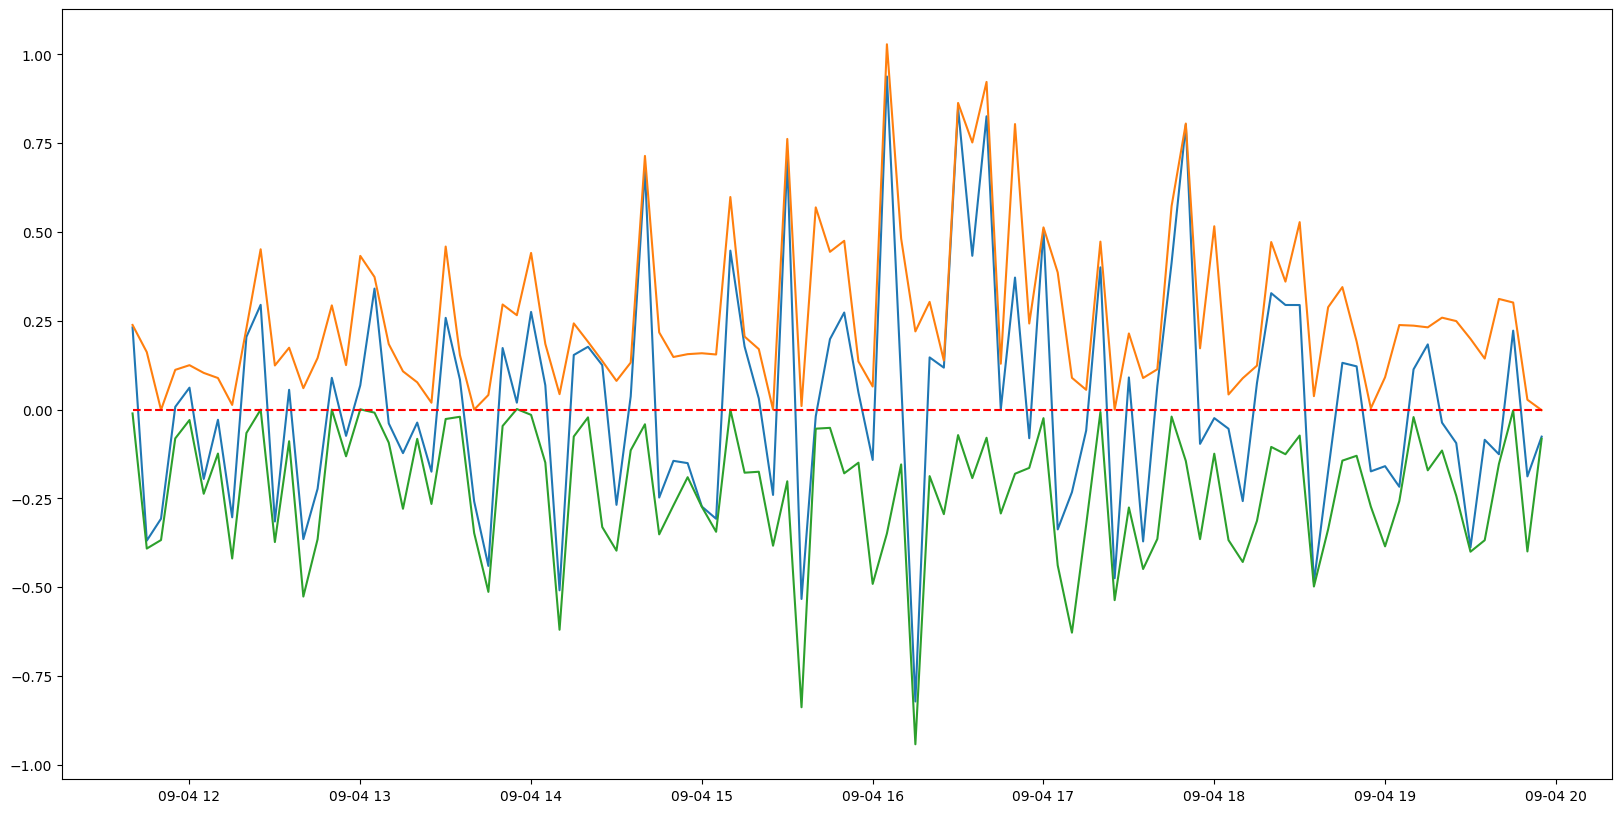

In [119]:
plt.figure(figsize=(20, 10))
plt.plot(df[columns_target][-100:])
plt.plot(df[columns_target][-100:].index,np.zeros(100), 'r--')

train_target mean = 1.911E-03, test_target mean = 1.459E-03
train_target mean = -1.152E-17, test_target mean = -2.851E-18


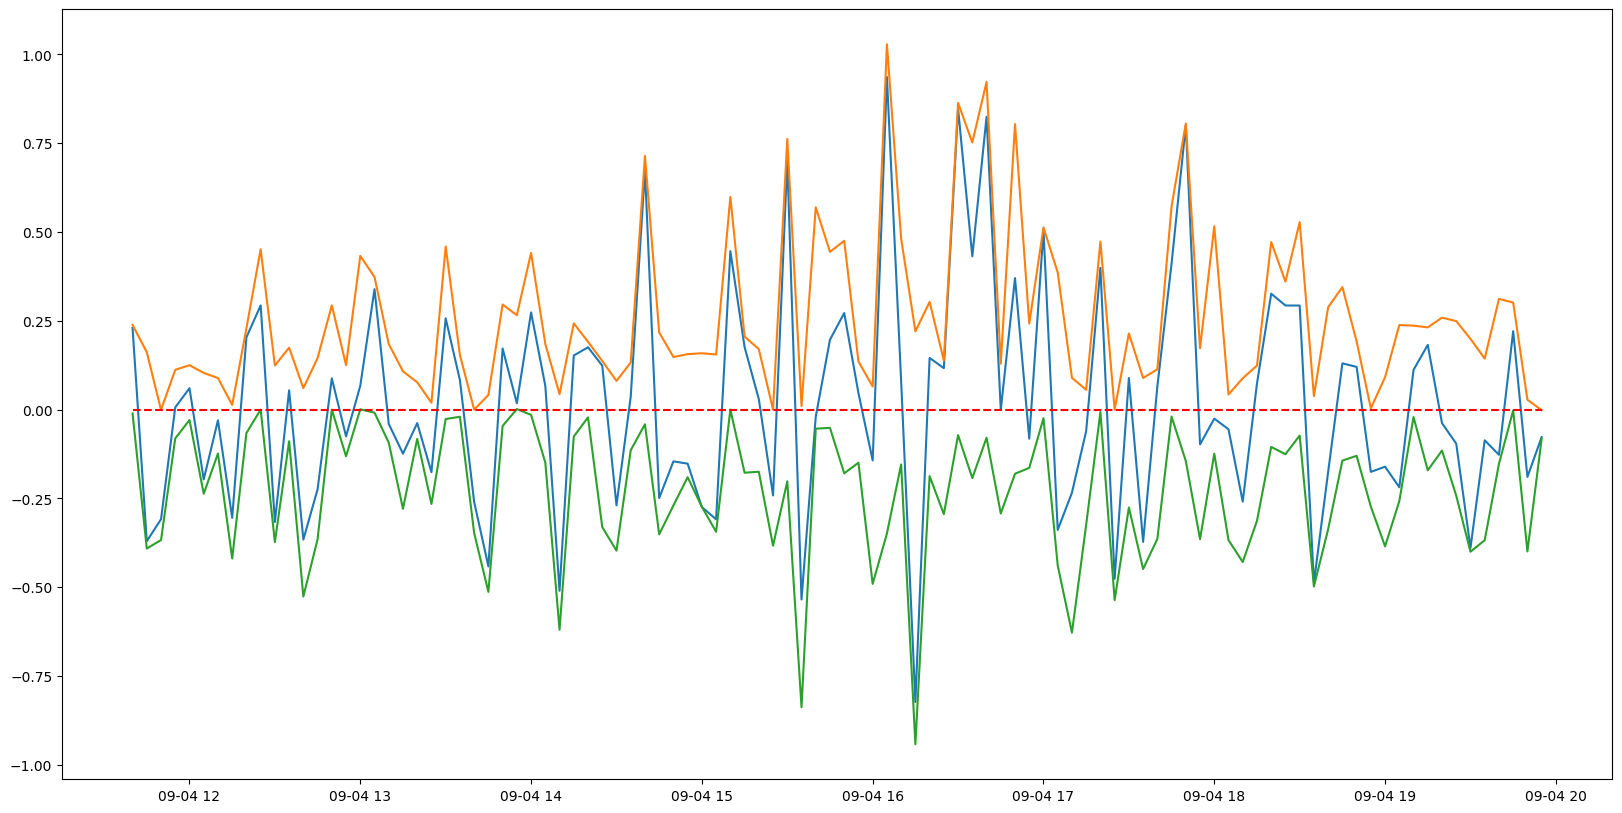

In [171]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

train_data, test_data = df[:int(len(data)*0.8)], df[int(len(data)*0.8):]

start_index = 0

train_target = train_data.loc[:, columns_target]

test_target = test_data.loc[:, columns_target]

train_target_mean = train_target.loc[:, columns_target[0]].mean()

print(f'train_target mean = {train_target_mean:.3E}, test_target mean = {test_target.loc[:, columns_target[0]].mean():.3E}')

train_target.loc[:, columns_target[0]] = train_target.loc[:, columns_target[0]] - train_target.loc[:, columns_target[0]].mean()
test_target.loc[:, columns_target[0]] = test_target.loc[:, columns_target[0]] - test_target.loc[:, columns_target[0]].mean()


print(f'train_target mean = {train_target.loc[:, columns_target[0]].mean():.3E}, test_target mean = {test_target.loc[:, columns_target[0]].mean():.3E}')

    

scaler = StandardScaler()


train_data = scaler.fit_transform(train_data.loc[:, columns_data]) 
test_data = scaler.transform(test_data.loc[:, columns_data])

plt.figure(figsize=(20, 10))
plt.plot(test_target[-100:])
plt.plot(test_target[-100:].index,np.zeros(100), 'r--')

train_target = train_target.to_numpy()
test_target = test_target.to_numpy()

In [172]:
class ExpInvestLoss(nn.Module):
    def __init__(self, alpha=0.1):
        super(ExpInvestLoss, self).__init__()
        self.alpha = alpha

    def forward(self, y_pred, y_true):
        
        return torch.exp(-y_true*y_pred*self.alpha).mean()
    
class InvestLoss(nn.Module):
    def __init__(self, alpha=0):
        super(InvestLoss, self).__init__()
        self.alpha = alpha
    def forward(self, y_pred, y_true):
        
        r = y_true*y_pred
        
        return -r.mean()
    
class ADILoss(nn.Module):
    def __init__(self, fee=0.04):
        super(ADILoss, self).__init__()
        self.fee = fee
    def forward(self, inv, diff_inv, returns):
        
        if not self.fee == 0:
            return -((inv*returns).mean() - self.fee * diff_inv.abs().mean())

        else:
            return -(inv*returns).mean()
        
class PDILoss(nn.Module):
    def __init__(self, fee=0.04, stop_loss_w=True):
        super(PDILoss, self).__init__()
        self.fee = fee
        self.stop_loss_w = stop_loss_w
    def forward(self, inv, diff_inv, rchl, leverage=0.1, return_array=False, stop_loss=torch.tensor(15)):

        returns = inv*rchl[:,0]
        
        if self.stop_loss_w:
            
            ichl = rchl * inv.unsqueeze(1)
            min_ichl = ichl.min(dim=1).values
            
            returns = torch.where(min_ichl <= -stop_loss, -stop_loss, returns)


        else:
            ichl = rchl * inv.sign().unsqueeze(1)
            min_ichl = ichl.min(dim=1).values
            
            returns = torch.where(min_ichl <= -stop_loss, -stop_loss*inv, returns)
        
        
        if not self.fee == 0:
            
            gain =  returns - self.fee * diff_inv.abs()
            
            prod_gain = (1+gain/100*leverage).clamp(0)
            
            if return_array:
                return prod_gain
            
            return -prod_gain.prod()

        else:
            return -(1 + returns/100).prod()**(1/len(inv)) - 1
        
class PDILoss2(nn.Module):
    def __init__(self, fee=0.04, stop_loss_w=True):
        super(PDILoss2, self).__init__()
        self.fee = fee
        self.stop_loss_w = stop_loss_w
    def forward(self, inv, diff_inv, rchl, leverage=0.1, return_array=False, stop_loss=torch.tensor(15)):
        
        diff_inv= inv.diff()

        returns = inv*rchl[:,0]
        
        ichl = rchl * inv.unsqueeze(1)
        min_ichl = ichl.min(dim=1).values
        
        returns = torch.where(min_ichl <= -stop_loss , -stop_loss, returns)
        
        add_diff = torch.where(min_ichl <= -stop_loss, -inv, 0)
        
        corected_diff = diff_inv - add_diff
        
        
        if not self.fee == 0:
            
            gain =  returns - self.fee * (diff_inv.abs() +  )
            
            prod_gain = (1+gain/100*leverage).clamp(0)
            
            if return_array:
                return prod_gain
            
            return -prod_gain.prod()

        else:
            return -(1 + returns/100).prod()**(1/len(inv)) - 1

In [180]:
train_src = torch.tensor(train_data[:-1], dtype=torch_dtype).to(device)
train_tgt = torch.tensor(train_target[1:], dtype=torch_dtype).to(device)

print(train_target[:, 0].mean())

test_src = torch.tensor(test_data[:-1], dtype=torch_dtype).to(device)
test_tgt = torch.tensor(test_target[1:], dtype=torch_dtype).to(device)


class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        
        seed = 3
        
        self.h = 16
        
        # torch.manual_seed(seed)
        self.l1 = nn.Linear(train_src.shape[1], self.h)
        # torch.manual_seed(seed)
        self.l2 = nn.Linear(self.h, 1)
        
        self.relu = nn.ReLU()   
        
        self.tanh = nn.Tanh()

    def forward(self, x):
        
        x = self.relu(self.l1(x))
        x = self.l2(x)
        
        return self.tanh(x)
    
    
model = Model().to(device=device, dtype=torch_dtype)
pleverage = nn.Parameter(torch.tensor(-1, dtype=torch_dtype))
pstop_loss = nn.Parameter(torch.tensor(1, dtype=torch_dtype))



optimizer = torch.optim.Adam(model.parameters(), lr=8e-2, amsgrad=True, weight_decay=1e-7)
opt_leverage = torch.optim.Adam([pleverage], lr=1e-1, amsgrad=True)
opt_stop_loss = torch.optim.Adam([pstop_loss], lr=1e-0, amsgrad=True)   

criterion = PDILoss(fee=0.04)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4000, gamma=0.9)

train_loss = []
test_loss = []

def run_model(model, src, tgt, return_array=False, leverage=0.1, stop_loss=15):
    
    inv = model(src).squeeze()
    diff_inv = torch.cat([torch.tensor([0.], device=device), inv]).diff()
    
    loss = criterion(inv, diff_inv, tgt, return_array=return_array, leverage=leverage, stop_loss=stop_loss)
    
    if return_array:
        return loss, inv
    return loss


num_epochs = 1000

for epoch in tqdm(range(num_epochs)):
    
    leverage = pleverage.sigmoid()
    stop_loss = (torch.tensor(0.01) + pstop_loss.exp())/leverage
    

    model.eval()
        
    test_loss.append((-run_model(model, test_src, test_tgt, leverage=leverage, stop_loss=stop_loss).detach().item())**(1/len(train_src)))
    
    model.train()
    optimizer.zero_grad()
    opt_leverage.zero_grad()
    opt_stop_loss.zero_grad()

    loss = run_model(model, train_src, train_tgt, leverage=leverage, stop_loss=stop_loss)
    loss.backward()
    

    optimizer.step()
    opt_leverage.step()
    
    scheduler.step()
    
    train_loss.append((-loss.detach().item())**(1/len(train_src)))

    
    if epoch % (num_epochs//20) == 0:
        opt_stop_loss.step()

        print(f'Epoch {epoch}: train loss {train_loss[-1]-1:.3E}, test loss {test_loss[-1]-1:.3E}, sl {stop_loss.item():.3E} leverage {leverage.item():.3E}')
        # print(pstop_loss.exp().item(), pleverage.sigmoid().item())



-1.1516020847745751e-17


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0: train loss -8.002E-06, test loss -2.148E-06, sl 1.014E+01 leverage 2.689E-01
Epoch 50: train loss 1.204E-05, test loss -5.755E-07, sl 1.164E+00 leverage 8.676E-01
Epoch 100: train loss 1.768E-05, test loss -1.032E-06, sl 4.855E-01 leverage 9.993E-01
Epoch 150: train loss 5.928E-05, test loss 5.596E-07, sl 2.540E-01 leverage 1.000E+00
Epoch 200: train loss 9.184E-05, test loss 6.649E-06, sl 1.464E-01 leverage 1.000E+00
Epoch 250: train loss 7.722E-05, test loss 3.913E-06, sl 8.907E-02 leverage 1.000E+00
Epoch 300: train loss 8.805E-05, test loss 8.399E-06, sl 5.928E-02 leverage 1.000E+00
Epoch 350: train loss 9.523E-05, test loss 1.086E-05, sl 4.045E-02 leverage 1.000E+00
Epoch 400: train loss 8.414E-05, test loss 1.262E-05, sl 2.587E-02 leverage 1.000E+00
Epoch 450: train loss 7.958E-05, test loss 1.303E-05, sl 1.886E-02 leverage 1.000E+00
Epoch 500: train loss 8.552E-05, test loss 1.285E-05, sl 1.526E-02 leverage 1.000E+00
Epoch 550: train loss 8.803E-05, test loss 1.278E-05,

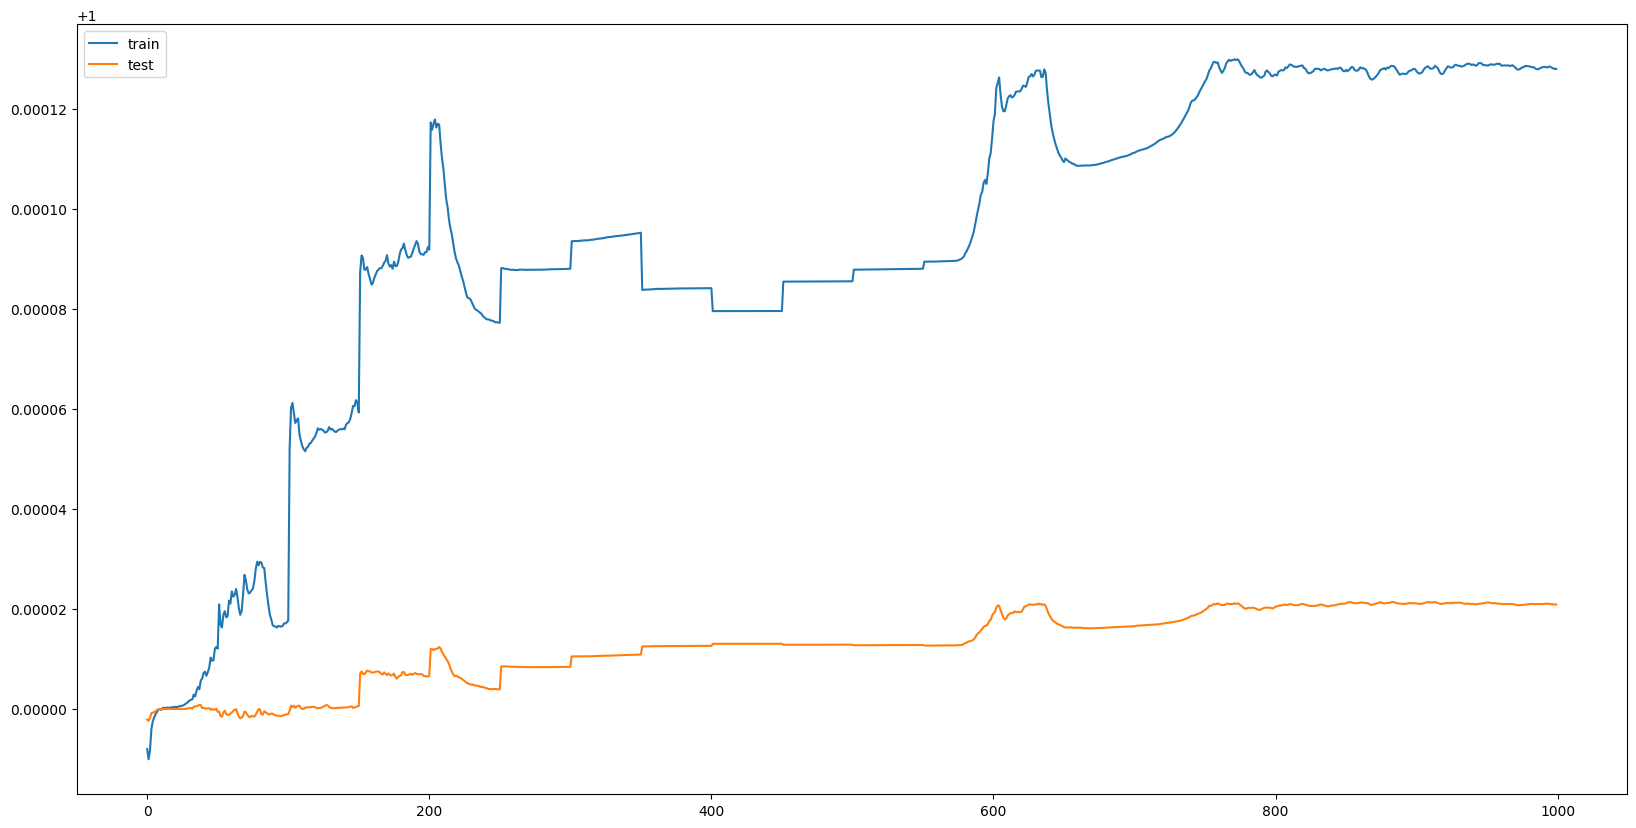

In [181]:
plt.figure(figsize=(20, 10))
plt.plot(train_loss, label='train')
plt.plot(test_loss, label='test')
plt.legend()

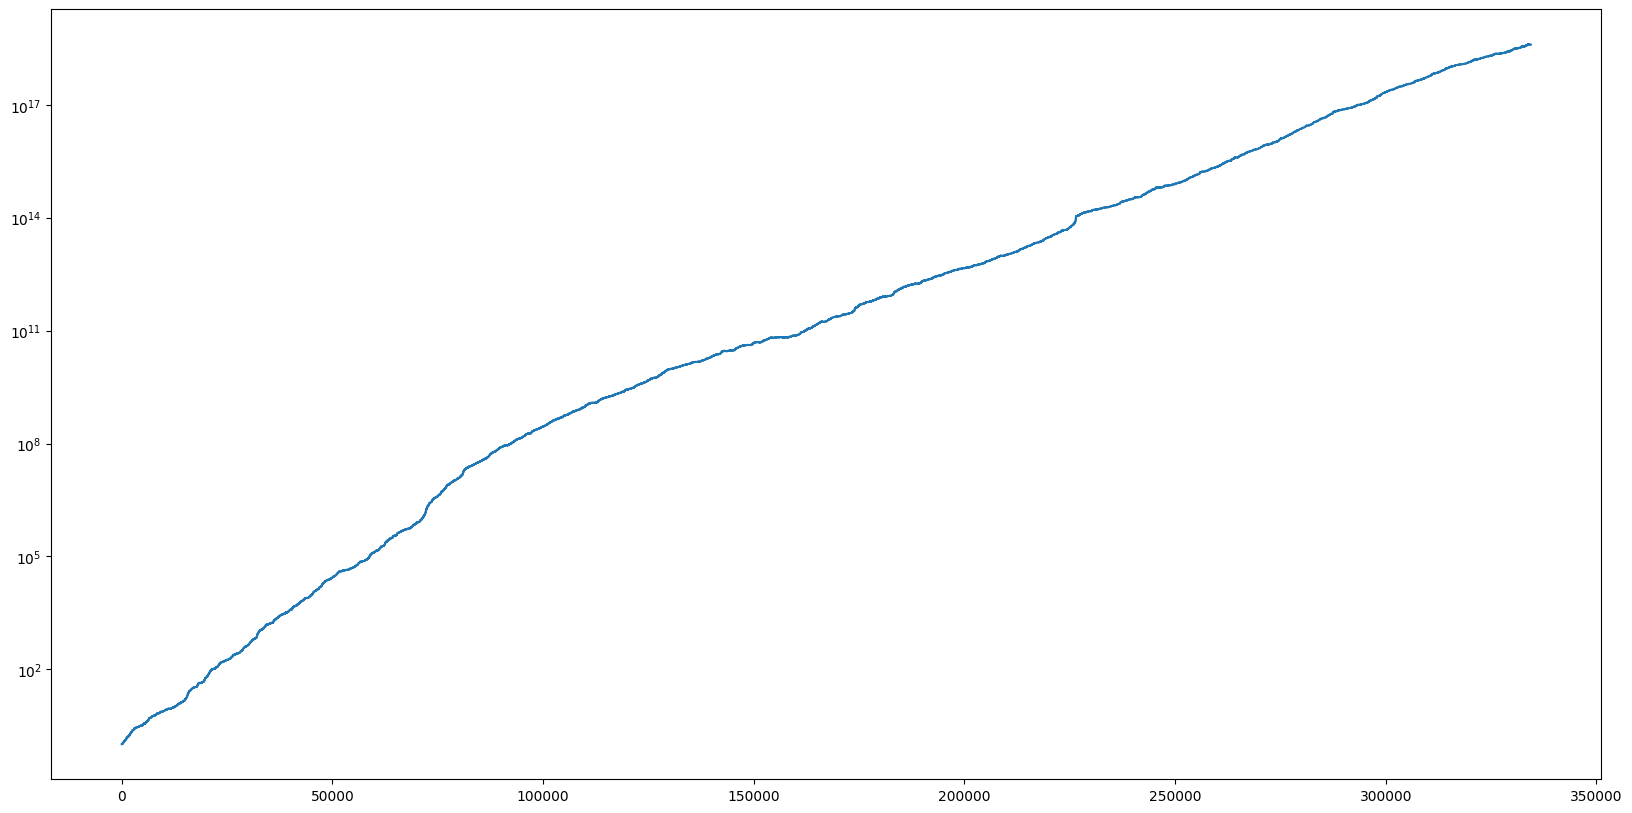

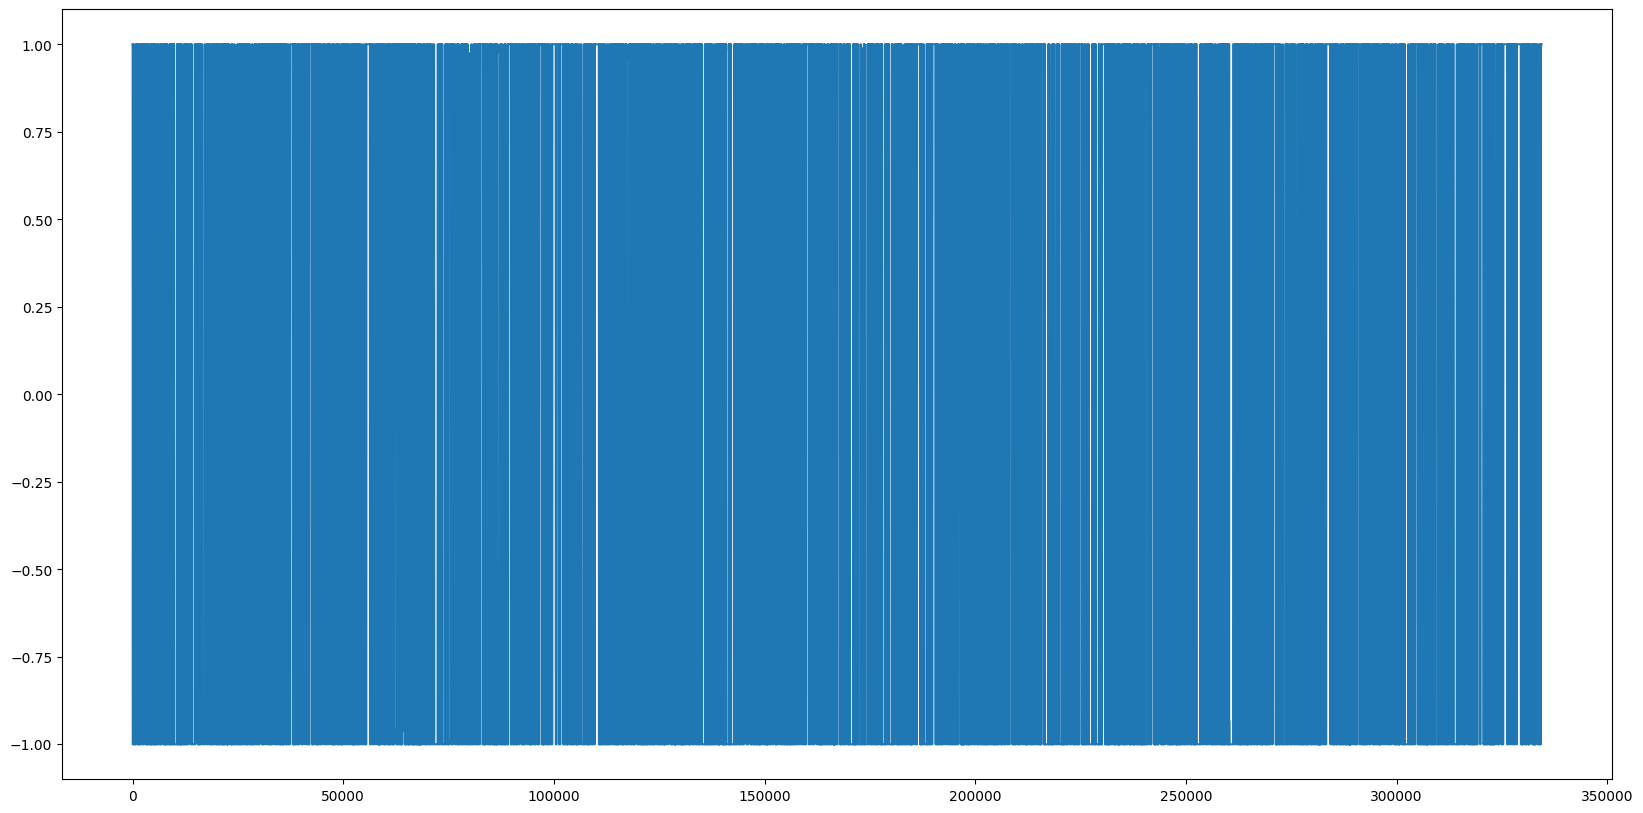

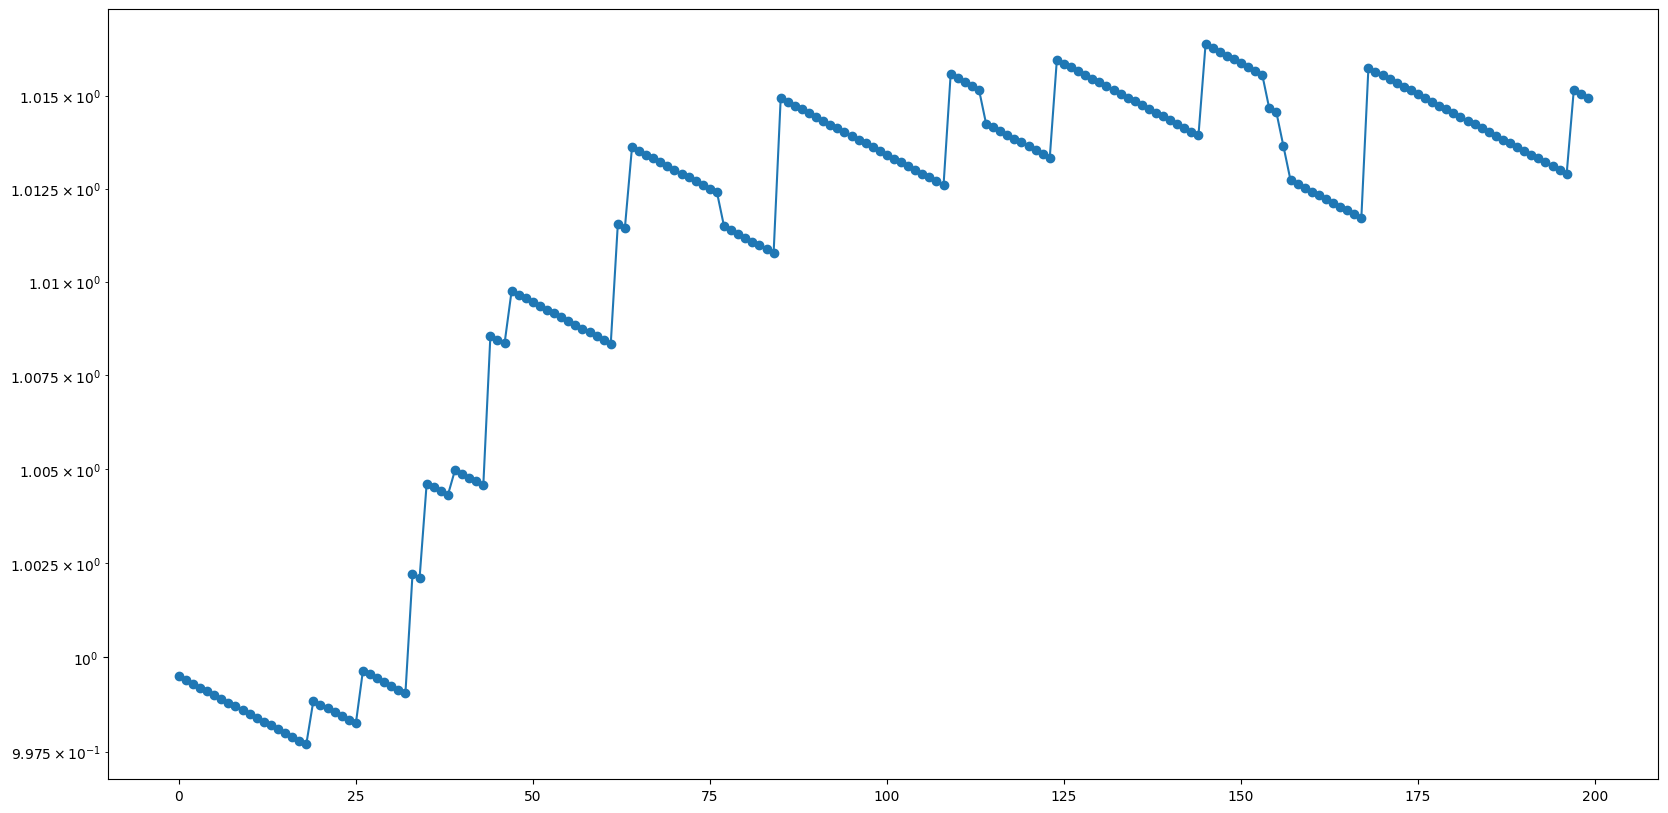

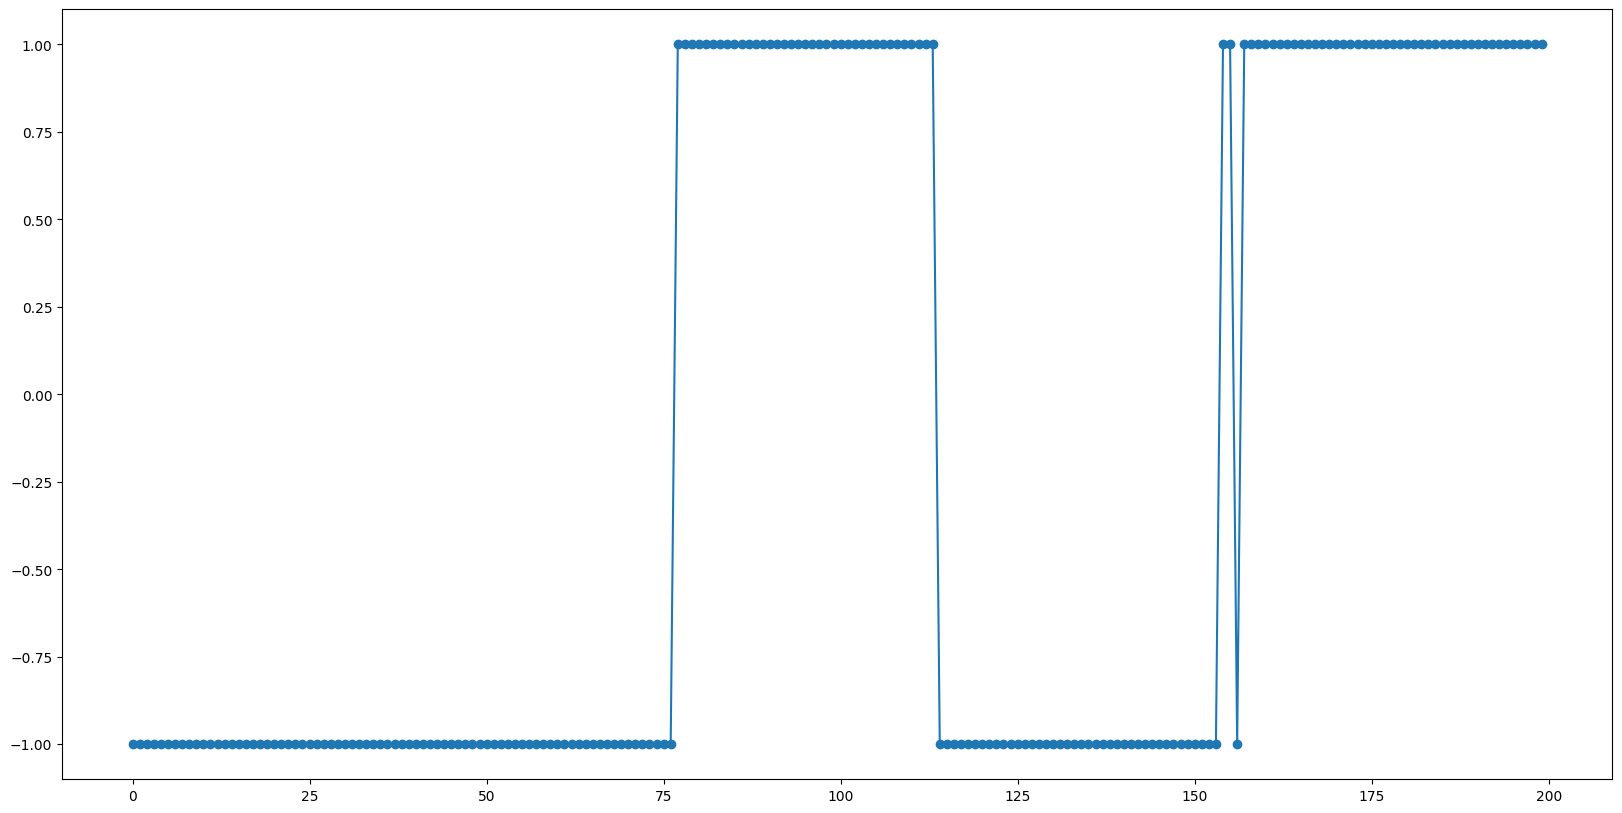

In [190]:

train_gain, train_inv = run_model(model, train_src, train_tgt, return_array=True, leverage=leverage.item(), stop_loss=stop_loss.item())
test_gain, test_inv = run_model(model, test_src[-200:], test_tgt[-200:], return_array=True, leverage=leverage.item(), stop_loss=stop_loss.item())

# train_gain = run_model(model, train_src, train_tgt, return_array=True, leverage=0.1)
# test_gain = run_model(model, test_src, test_tgt, return_array=True, leverage=0.1)

plt.figure(figsize=(20, 10))
plt.plot(train_gain.cpu().detach().numpy().cumprod(), label='train')
plt.yscale('log')
plt.show()

plt.figure(figsize=(20, 10))
plt.plot(train_inv.cpu().detach().numpy(), label='train')
plt.show()


plt.figure(figsize=(20, 10))
plt.plot(test_gain.cpu().detach().numpy().cumprod(), 'o-', label='test')
plt.yscale('log')
plt.show()

plt.figure(figsize=(20, 10))
plt.plot(test_inv.cpu().detach().numpy(), 'o-', label='train_tgt')